# DBSCAN–Louvain analysis of the firearm-homicide knowledge graph

## Purpose

This notebook documents the **DBSCAN → Louvain** configuration evaluated in the paper. DBSCAN is first applied to standardized spatial, temporal, and demographic attributes. A selected DBSCAN cluster is then connected to coordinate nodes in the knowledge graph, a local graph substructure is extracted, and Louvain community detection is applied to that subgraph.

The workflow contains five analytical layers:

1. **Preprocessing:** load homicide records, restrict the study period to 2017–2022, and derive encoded variables.
2. **DBSCAN:** standardize five features, inspect a k-distance curve, and compare candidate `eps` values.
3. **Graph projection:** connect the selected DBSCAN cluster to coordinate nodes in the serialized knowledge graph and construct a local subgraph.
4. **Louvain:** optimize modularity within the extracted graph substructure and characterize the resulting communities.
5. **Cartographic post-processing:** reconnect Louvain communities to geographic points, add AGEB poverty information, and explore distance-constrained spatial groups.

> **Scope note.** The sequential method ends with the Louvain partition of the DBSCAN-derived graph substructure. The later poverty, seed-selection, and distance-based grouping cells are exploratory cartographic post-processing and are not part of either DBSCAN or Louvain.

## Saved execution

| Quantity | Stored value |
|---|---:|
| Input homicide records | 4,021 |
| Candidate `eps` values | 0.40, 0.45, 0.50 |
| Selected DBSCAN result | `eps=0.50`, `min_samples=5` |
| DBSCAN labels, including noise | 23 |
| Manually selected DBSCAN label | 6 (92 records) |
| Full knowledge graph | 23,540 nodes; 99,733 edges |
| Extracted graph substructure | 2,114 nodes |
| Louvain communities in substructure | 22 |
| Louvain modularity | 0.437456 |

## Reproducibility

- Louvain random state: `123`.
- DBSCAN is deterministic for a fixed input order and feature matrix.
- The original executable code, execution counts, and stored outputs are preserved.
- Truly empty cells from the source notebook are removed.
- Added Markdown and `Annotation` comments explain the role and limitations of each retained cell.


In [1]:
# Annotation: Import numerical, clustering, graph, RDF, and geospatial libraries used throughout the workflow.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import plotly.express as px
import numpy as np
import math
import pandas as pd
from shapely.geometry import Polygon, LineString, Point, MultiPolygon
import rdflib
from rdflib import Namespace, URIRef, BNode
from rdflib.namespace import RDF, FOAF, OWL, RDFS, XSD
from time import time #importamos la función time para capturar tiempos
import ontospy
from ontospy import *
import numpy as np
import matplotlib.pyplot as plt

import networkx as nx
#import kglab
import os
import igraph as ig
import leidenalg as la
import community as community_louvain
import networkx.algorithms.community as nx_comm
import geopandas as gpd
import json
from sklearn.cluster import DBSCAN 

## 1. Data loading and preprocessing

The workflow reads the incident-level homicide table and AGEB contextual data, fills selected missing values, limits records to 2017–2022, and derives numerical features for clustering.

Missing age is recoded as zero in the original implementation. Consequently, unknown ages are placed in the first age group. In addition, the declared labels do not match the intervals produced by `[0, 18, 64, inf]` with `right=False`: ages 18 and 64 enter the second and third intervals, respectively.


In [6]:
# Annotation: Load the homicide records and AGEB-level contextual table.
carpetas=pd.read_csv('homicidioscdmx.csv')
agebinfo=pd.read_csv('agebspob.csv')

In [7]:
# Annotation: Inspect the original homicide-table dimensions, columns, data types, and missing values.
carpetas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4021 entries, 0 to 4020
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0.1          4021 non-null   int64  
 1   index                 4021 non-null   int64  
 2   Unnamed: 0            4021 non-null   int64  
 3   idCarpeta             4021 non-null   float64
 4   Año_inicio            4021 non-null   int64  
 5   Mes_inicio            4021 non-null   object 
 6   FechaInicio           4021 non-null   object 
 7   Delito                4021 non-null   object 
 8   Categoria             4021 non-null   object 
 9   Sexo                  4021 non-null   object 
 10  Edad                  4021 non-null   object 
 11  TipoPersona           4017 non-null   object 
 12  CalidadJuridica       4021 non-null   object 
 13  competencia           4021 non-null   object 
 14  Año_hecho             4021 non-null   float64
 15  Mes_hecho            

In [8]:
# Annotation: Replace missing neighborhood, sex, and age values with the explicit category 'No especificado'.
carpetas['colonia_datos'].replace(np.NaN,'No especificado',inplace=True)
carpetas['Sexo'].replace(np.NaN,'No especificado',inplace=True)
carpetas['Edad'].replace(np.NaN,'No especificado',inplace=True)


In [9]:
# Annotation: Restrict the study period to 2017–2022 and inspect the filtered table.
carpetas=carpetas[(carpetas['Año_hecho']>=2017) & (carpetas['Año_hecho']<=2022)]
carpetas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4021 entries, 0 to 4020
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0.1          4021 non-null   int64  
 1   index                 4021 non-null   int64  
 2   Unnamed: 0            4021 non-null   int64  
 3   idCarpeta             4021 non-null   float64
 4   Año_inicio            4021 non-null   int64  
 5   Mes_inicio            4021 non-null   object 
 6   FechaInicio           4021 non-null   object 
 7   Delito                4021 non-null   object 
 8   Categoria             4021 non-null   object 
 9   Sexo                  4021 non-null   object 
 10  Edad                  4021 non-null   object 
 11  TipoPersona           4017 non-null   object 
 12  CalidadJuridica       4021 non-null   object 
 13  competencia           4021 non-null   object 
 14  Año_hecho             4021 non-null   float64
 15  Mes_hecho            

In [10]:
# Annotation: Derive radian coordinates and encoded year, age-group, and sex features.
carpetas['longitudrad'] = np.radians(carpetas.longitud)
carpetas['latitudrad'] = np.radians(carpetas.latitud)
carpetas.Edad.replace('No especificado','0.0',inplace=True)
carpetas.Edad = carpetas.Edad.astype(float)
carpetas.Edad = carpetas.Edad.astype(int)
edades = [0, 18, 64, float('inf')]
# Etiquetas para los grupos etarios
etiquetas_edad = ['0-18', '19-64', '65+']
mapeo2 = {'0-18': 1, '19-64': 2, '65+': 3}


carpetas['grupo_etario'] = pd.cut(carpetas['Edad'], bins=edades, labels=etiquetas_edad, right=False)
carpetas['grupo_etario2'] = carpetas['grupo_etario'].map(mapeo2)
carpetas['genero2'] = carpetas['Sexo'].replace({'Masculino':1,'Femenino':2,'No especificado':3})
carpetas['año'] = carpetas['Año_hecho']


In [11]:
# Annotation: Display the preprocessed homicide records for an exploratory check.
carpetas

,Unnamed: 0.1,index,Unnamed: 0,idCarpeta,Año_inicio,Mes_inicio,FechaInicio,Delito,Categoria,Sexo,...,latitud,longitud,ageb,shp,longitudrad,latitudrad,grupo_etario,grupo_etario2,genero2,año
0,0,188,192,8325049.0,2019,Enero,2019-01-05,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.237800,-99.144230,0813,NaN,-1.730393,0.335763,19-64,2,1,2019.0
1,1,384,389,8325655.0,2019,Enero,2019-01-06,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.395180,-99.193390,1773,NaN,-1.731251,0.338510,19-64,2,1,2019.0
2,2,454,460,8325855.0,2019,Enero,2019-01-06,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.366760,-99.087920,0750,NaN,-1.729410,0.338014,19-64,2,1,2019.0
3,3,512,520,8326053.0,2019,Enero,2019-01-07,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.272320,-99.135920,0067,NaN,-1.730248,0.336365,19-64,2,1,2019.0
4,4,519,527,8326074.0,2019,Enero,2019-01-07,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.309127,-99.206300,1307,NaN,-1.731477,0.337008,19-64,2,1,2019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4016,4140,965826,973633,9361524.0,2022,Diciembre,2022-12-30,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.441201,-99.119868,0371,NaN,-1.729968,0.339313,0-18,1,1,2022.0
4017,4141,968068,978150,9366167.0,2023,Enero,2023-01-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.361090,-99.031424,1091,NaN,-1.728424,0.337915,19-64,2,1,2022.0
4018,4142,968069,978151,9366167.0,2023,Enero,2023-01-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.361090,-99.031424,1091,NaN,-1.728424,0.337915,0-18,1,1,2022.0
4019,4143,968070,978152,9366167.0,2023,Enero,2023-01-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Femenino,...,19.361090,-99.031424,1091,NaN,-1.728424,0.337915,19-64,2,2,2022.0


## 2. DBSCAN feature matrix

DBSCAN uses latitude, longitude, year, age group, and sex. Coordinates are converted to radians, while age group and sex are integer-encoded. Treating categorical codes as continuous numerical distances imposes an ordering that should be justified or replaced by an appropriate mixed-data distance.


In [12]:
# Annotation: Assemble the five-variable feature matrix used by DBSCAN.
X=carpetas[['latitudrad','longitudrad','año','grupo_etario2','genero2']].to_numpy()

## 3. Standardization and neighbourhood-distance analysis

All five input variables are standardized before DBSCAN so that differences in scale do not dominate the Euclidean distance. A 10-nearest-neighbour distance curve is used to inspect a plausible neighbourhood radius.


In [13]:
# Annotation: Import standardization and nearest-neighbour utilities.
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [14]:
# Annotation: Standardize the DBSCAN feature matrix to zero mean and unit variance.
st = StandardScaler()
stdDf = pd.DataFrame(st.fit_transform(X))

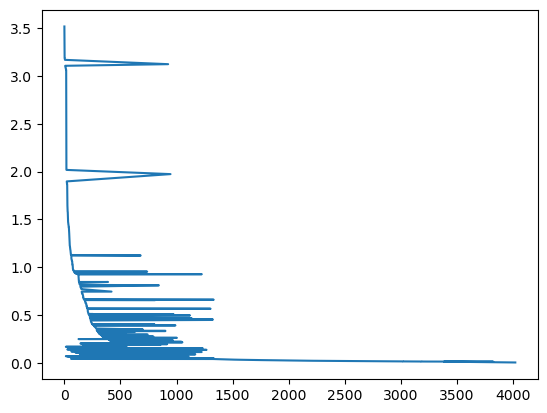

In [15]:
# Annotation: Calculate 10-nearest-neighbour distances and draw an initial descending distance curve.
ns = 10
nbrs = NearestNeighbors(n_neighbors=ns).fit(stdDf)
distances, indices = nbrs.kneighbors(stdDf)
distanceDec = sorted(distances[:,ns-1], reverse=True)
plt.plot(indices[:,0], distanceDec)

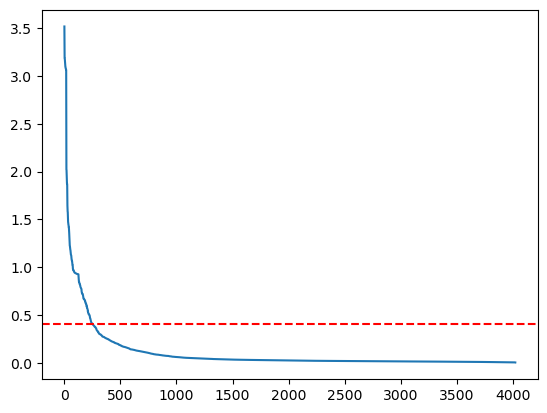

In [16]:
# Annotation: Plot the ordered 10-neighbour distances and mark 0.4 as a candidate elbow threshold.
plt.plot(list(range(1,len(indices)+1)), distanceDec)
plt.axhline(y=0.4,color='red',linestyle='--')

## 4. DBSCAN parameter comparison

Three candidate radii are evaluated with `min_samples=5`. The resulting label arrays are stored separately so their cluster-size distributions can be compared. The subsequent analysis uses the third configuration (`eps=0.50`).


In [17]:
# Annotation: Define the three candidate DBSCAN neighbourhood radii.
epsilo=[0.4,0.45,.5]

In [18]:
# Annotation: Fit DBSCAN for every candidate radius using five minimum samples and store labels and core points.
# Crea un diccionario para almacenar los resultados de DBSCAN
resultados_dbscan = {}

# Itera sobre los valores de epsilon
for epsilon in epsilo:
    # Crea una instancia de DBSCAN con el valor actual de epsilon
    dbscan = DBSCAN(eps=epsilon, min_samples=5)
    
    # Ajusta el modelo a tus datos
    dbscan.fit(stdDf)
    
    # Almacena los resultados en el diccionario
    resultados_dbscan[epsilon] = {
        'labels': dbscan.labels_,
        'core_sample_indices': dbscan.core_sample_indices_
    }


In [19]:
# Annotation: Attach the three candidate DBSCAN partitions to the incident table.
carpetas['cluster1'] = resultados_dbscan[epsilo[0]]['labels']
carpetas['cluster2'] = resultados_dbscan[epsilo[1]]['labels']
carpetas['cluster3'] = resultados_dbscan[epsilo[2]]['labels']


In [20]:
# Annotation: Compare cluster and noise counts across the three DBSCAN configurations.
# Utiliza value_counts() para contar el número de ocurrencias de cada valor único
conteo_valores1 = carpetas['cluster1'].value_counts()
conteo_valores2 = carpetas['cluster2'].value_counts()
conteo_valores3 = carpetas['cluster3'].value_counts()

# Muestra los resultados
print(conteo_valores1,conteo_valores2,conteo_valores3)

cluster1
 0     1116
 6      908
 14     689
 19     482
 1      118
-1       95
 16      93
 7       91
 15      64
 21      61
 10      61
 3       48
 20      42
 8       27
 25      23
 5       16
 2       16
 9       14
 22      10
 4        9
 11       6
 23       6
 24       6
 13       5
 18       5
 17       5
 12       5
Name: count, dtype: int64 cluster2
 0     1116
 5      908
 12     689
 17     482
 1      118
 14      93
 6       91
 7       88
-1       87
 2       64
 13      64
 19      61
 18      42
 22      30
 8       17
 4       17
 3       12
 20      10
 21       6
 9        6
 10       5
 11       5
 16       5
 15       5
Name: count, dtype: int64 cluster3
 0     1116
 5      908
 11     689
 16     482
 1      118
 7       94
 13      93
 6       92
-1       79
 12      67
 2       64
 18      61
 17      42
 21      30
 4       18
 8       17
 3       13
 19      10
 14       6
 20       6
 9        6
 10       5
 15       5
Name: count, dtype: int64


## 5. DBSCAN validation

The notebook reports silhouette scores with and without the noise label. These scores are computed from the unstandardized `community_data`, although DBSCAN was fitted to `stdDf`. A methodologically consistent evaluation should calculate silhouette in the same standardized feature space used for clustering.


In [21]:
# Annotation: Select the third DBSCAN partition and reconstruct its feature table for validation.
# Supongamos que 'community_id' identifica la comunidad en la tabla
community_data = carpetas[['latitudrad','longitudrad','año','grupo_etario2','genero2',]]
community_labels =carpetas['cluster3']

In [22]:
# Annotation: Calculate the silhouette coefficient after excluding DBSCAN noise points.
from sklearn.metrics import silhouette_score

# Filtrar datos excluyendo el ruido
valid_indices = community_labels != -1
filtered_data = community_data[valid_indices]
filtered_labels = community_labels[valid_indices]

# Calcular Silhouette Score si hay más de un clúster válido
if len(set(filtered_labels)) > 1:
    silhouette = silhouette_score(filtered_data, filtered_labels)
    print(f"Silhouette Score (excluyendo ruido): {silhouette}")
else:
    print("No se puede calcular el Silhouette Score: menos de 2 clústeres válidos.")


Silhouette Score (excluyendo ruido): 0.9882965095815197


In [23]:
# Annotation: Calculate a second silhouette coefficient while treating noise as an additional label.
# Calcular Silhouette Score incluyendo el ruido
if len(set(community_labels)) > 1:
    silhouette_with_noise = silhouette_score(community_data, community_labels)
    print(f"Silhouette Score (incluyendo ruido): {silhouette_with_noise}")
else:
    print("No se puede calcular el Silhouette Score: menos de 2 clústeres.")

Silhouette Score (incluyendo ruido): 0.9540218364170584


In [24]:
# Annotation: Count distinct labels in the selected DBSCAN partition, including noise when present.
carpetas.cluster3.nunique()

23

## 6. Select the DBSCAN cluster for graph projection

The code retains DBSCAN label `6` from the `eps=0.50` partition. DBSCAN labels are arbitrary identifiers, so selecting a fixed number is not stable when data order, preprocessing, or parameters change. The publication workflow should state the substantive selection rule or choose the target automatically—for example, by case count, geographic focus, or a predeclared quality criterion.

The variable `carpfuego1` contains only firearm homicides, but the next assignment sets `carpfuego=carpetas`; therefore, the executed selection is not restricted by `Delito` at this point.


In [25]:
# Annotation: Create a firearm-only subset but retain the complete table for the executed downstream analysis.
carpfuego1=carpetas[(carpetas['Delito']=='HOMICIDIO_POR_ARMA_DE_FUEGO')]
#carpfuego2=carpetas[(carpetas['Delito']=='HOMICIDIO_POR_ARMA_BLANCA')]
carpfuego=carpetas
carpfuego

,Unnamed: 0.1,index,Unnamed: 0,idCarpeta,Año_inicio,Mes_inicio,FechaInicio,Delito,Categoria,Sexo,...,shp,longitudrad,latitudrad,grupo_etario,grupo_etario2,genero2,año,cluster1,cluster2,cluster3
0,0,188,192,8325049.0,2019,Enero,2019-01-05,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,NaN,-1.730393,0.335763,19-64,2,1,2019.0,0,0,0
1,1,384,389,8325655.0,2019,Enero,2019-01-06,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,NaN,-1.731251,0.338510,19-64,2,1,2019.0,0,0,0
2,2,454,460,8325855.0,2019,Enero,2019-01-06,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,NaN,-1.729410,0.338014,19-64,2,1,2019.0,0,0,0
3,3,512,520,8326053.0,2019,Enero,2019-01-07,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,NaN,-1.730248,0.336365,19-64,2,1,2019.0,0,0,0
4,4,519,527,8326074.0,2019,Enero,2019-01-07,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,NaN,-1.731477,0.337008,19-64,2,1,2019.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4016,4140,965826,973633,9361524.0,2022,Diciembre,2022-12-30,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,NaN,-1.729968,0.339313,0-18,1,1,2022.0,20,18,17
4017,4141,968068,978150,9366167.0,2023,Enero,2023-01-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,NaN,-1.728424,0.337915,19-64,2,1,2022.0,19,17,16
4018,4142,968069,978151,9366167.0,2023,Enero,2023-01-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,NaN,-1.728424,0.337915,0-18,1,1,2022.0,20,18,17
4019,4143,968070,978152,9366167.0,2023,Enero,2023-01-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Femenino,...,NaN,-1.728424,0.337915,19-64,2,2,2022.0,21,19,18


In [26]:
# Annotation: Select DBSCAN label 6 and inspect the years represented by its 92 records.
cluster1=carpfuego[carpfuego['cluster3']==6]
cluster1.Año_hecho

1346    2020.0
1352    2020.0
1376    2020.0
1377    2020.0
1387    2020.0
         ...  
2418    2020.0
2424    2020.0
2437    2020.0
2439    2020.0
2608    2020.0
Name: Año_hecho, Length: 92, dtype: float64

## 7. Convert the selected records to graph-compatible coordinates

Longitude and latitude are converted into the string representation used by coordinate nodes in the knowledge graph. This exact string-based linkage is sensitive to formatting and floating-point precision; a stable identifier or tolerance-based spatial join would be more robust.


In [27]:
# Annotation: Extract longitude and latitude arrays from the selected DBSCAN cluster.
longitudes=cluster1.longitud.values
latitudes=cluster1.latitud.values

In [28]:
# Annotation: Serialize each coordinate pair using the string format employed by graph coordinate nodes.
# Convertir a arrays del tipo 'd' (double)
import array
coordenadas = [(array.array('d', [lon]), array.array('d', [lat])) for lon, lat in zip(longitudes, latitudes)]
for i in range(0,len(coordenadas)):
    coordenadas[i] = str(coordenadas[i])

In [29]:
# Annotation: Inspect the first serialized coordinate identifier.
coordenadas[0]

"(array('d', [-99.0956683999732]), array('d', [19.4489915965352]))"

In [30]:
# Annotation: Create Shapely point geometries from the selected cluster coordinates.
Puntos=[Point(lon,lat) for lon, lat in zip(longitudes, latitudes)]

In [31]:
# Annotation: Construct a point GeoDataFrame for the selected DBSCAN cluster.
gdf1=gpd.GeoDataFrame(geometry=Puntos)

## 8. Preliminary cartographic check

The selected DBSCAN points are plotted over the AGEB poverty layer. The point GeoDataFrame is created without an explicit CRS, even though its coordinates are longitude and latitude; assigning `EPSG:4326` would make the overlay explicit and safer.


In [32]:
# Annotation: Load the AGEB poverty polygons and convert them to EPSG:4326.
alcal=gpd.read_file('ageb_pobreza.shp')
alcal=alcal.to_crs('EPSG:4326')

ERROR:fiona._env:PROJ: proj_identify: C:\Program Files\PostgreSQL\13\share\contrib\postgis-3.1\proj\proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR:fiona._env:PROJ: proj_identify: C:\Program Files\PostgreSQL\13\share\contrib\postgis-3.1\proj\proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.


<Axes: >

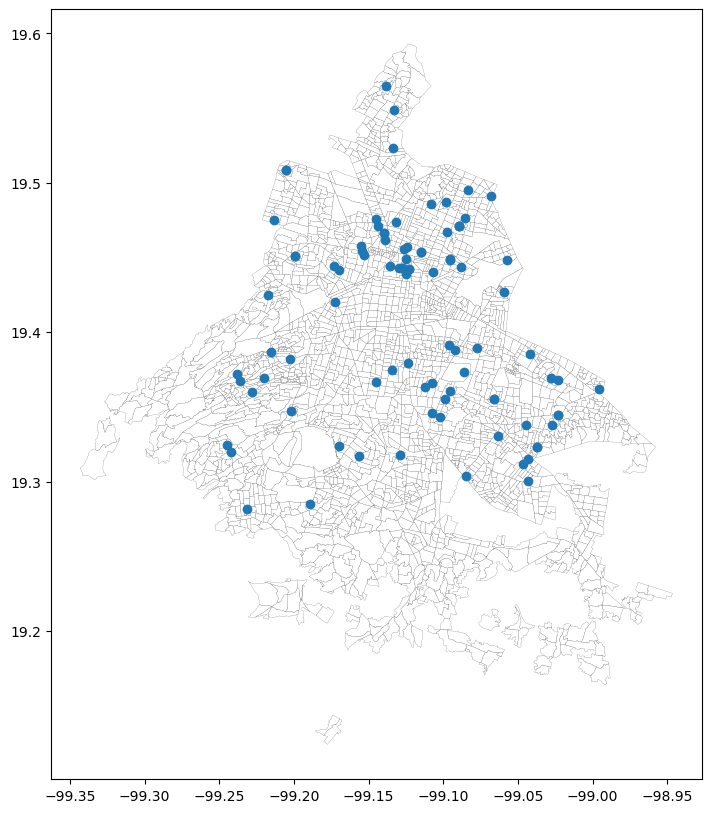

In [33]:
# Annotation: Plot the selected DBSCAN points over the AGEB reference polygons.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.1)
gdf1.plot(ax=ax)

In [34]:
# Annotation: Reconfirm the number of labels in the selected DBSCAN partition.
carpetas.cluster3.nunique()

23

## 9. Graph helper functions

These functions report graph characteristics, convert the node-to-community dictionary returned by `python-louvain` into lists of nodes, and test whether induced community subgraphs are connected.


In [35]:
# Annotation: Define a utility that reports graph size, clustering, and connected components.
def get_graph_info(graph):
    print("Number of nodes:", graph.number_of_nodes())
    print("Number of edges:", graph.number_of_edges())
    print("Average Cluster Coefficients:", nx.average_clustering(graph))
    print("Connected components:", len(list(nx.connected_components(graph))))

In [36]:
# Annotation: Convert a Louvain node-to-community dictionary into lists of member nodes.
 
def convert_communities_dict_to_list(communities_dict):
    unique_partition_count = len(list(set(communities_dict.values())))
    print("Number of unique communities:", unique_partition_count)
    communities = [[] for i in range(unique_partition_count)]
    for node in communities_dict.keys():
        communities[communities_dict[node]].append(node)
    return communities

In [37]:
# Annotation: Define a diagnostic that tests whether induced community subgraphs are connected.
# function to check whether the determined communities are connected
def check_community_disconnection(graph, communities):
    total_connected = 0
    disconnected_community_indexes = []
    for i in range(len(communities)):
        if nx.is_connected(graph.subgraph(communities[i])):
            total_connected += 1
        else:
            disconnected_community_indexes.append(i)
    print("Total Communities:", len(communities))
    print("Total Communities Connected:", total_connected)
    print("Disconnected Community Indexes:", disconnected_community_indexes)

## 10. Load the complete knowledge graph

The graph is reconstructed from NetworkX node-link JSON. The source notebook expects `grafoarmfuego3.json`; this exact file must accompany the notebook or the path must be changed to the graph version included in the public repository.


In [38]:
# Annotation: Deserialize the complete knowledge graph from NetworkX node-link JSON.
# Carga el grafo desde el archivo JSON
with open("grafoarmfuego3.json", "r") as json_file:
    graph_data = json.load(json_file)

# Crea un grafo de NetworkX a partir de los datos cargados
G = nx.readwrite.json_graph.node_link_graph(graph_data)


In [39]:
# Annotation: Display the graph's complete node view for exploratory inspection.
G.nodes()

NodeView(('http://localhost/8391317', '45.0', 'http://localhost/8700572', 'http://localhost/TLAHUAC', 'http://localhost/8859065', 'http://localhost/ALGARIN_CUAUHTEMOC', 'http://localhost/9181299', 'http://localhost/DELITO_DE_BAJO_IMPACTO', 'http://localhost/8385766', '25.0', 'http://localhost/8369624', 'http://localhost/AGEB0246', 'http://localhost/VILLA_COYOACAN_COYOACAN', 'http://localhost/ontology2#Lugar', 'http://localhost/AGEB0049', '[ 18, 34]', 'http://localhost/9358988', 'http://localhost/AGEB0211', 'http://localhost/9159937', 'Masculino', 'http://localhost/8516868', 'http://localhost/HOMICIDIO_POR_GOLPES', 'http://localhost/8770667', 'http://localhost/HOMICIDIO_DOLOSO', 'http://localhost/9007692', '2021-06-22', 'http://localhost/8393030', 'http://localhost/8656567', 'http://localhost/SAN_ANDRES_TOTOLTEPEC_(PBLO)_TLALPAN', 'http://localhost/9361443', 'Femenino', 'http://localhost/8543526', '65.0', 'http://localhost/AGEB1440', "(array('d', [-99.08728]), array('d', [19.2253]))", '

In [40]:
# Annotation: Report the number of nodes and edges in the full knowledge graph.
# Número de nodos y enlaces
num_nodos = G.number_of_nodes()
num_enlaces = G.number_of_edges()

print("Número de nodos:", num_nodos)
print("Número de enlaces:", num_enlaces)



Número de nodos: 23540
Número de enlaces: 99733


## 11. Build the DBSCAN-derived graph substructure

Coordinate nodes associated with the selected DBSCAN cluster are located in the full graph. Their neighbours are expanded by one additional step and used to induce `Gsub`.

The preserved implementation stores only neighbours of the first-order nodes. Although this generally recovers the coordinate nodes in an undirected graph, it does not explicitly union the seed, first-order, and second-order node sets. A formal two-hop ego-subgraph implementation should include all three sets directly.


In [41]:
# Annotation: Initialize the graph object that will hold the DBSCAN-derived substructure.
# Crear el grafo de conocimiento
Gsub = nx.Graph()


In [42]:
# Annotation: Convert selected incident identifiers to integer-formatted strings for graph matching.
ids=cluster1.idCarpeta.values.tolist()
ids=[str(int(id)) for id in ids]

In [43]:
# Annotation: Display all serialized coordinate identifiers from the selected DBSCAN cluster.
coordenadas

["(array('d', [-99.0956683999732]), array('d', [19.4489915965352]))",
 "(array('d', [-99.2021616509857]), array('d', [19.3475271369476]))",
 "(array('d', [-99.0374279669032]), array('d', [19.323186366422]))",
 "(array('d', [-99.0374279669032]), array('d', [19.323186366422]))",
 "(array('d', [-99.2447976674646]), array('d', [19.3246212234832]))",
 "(array('d', [-99.0466303500471]), array('d', [19.3116795905881]))",
 "(array('d', [-99.1534570999217]), array('d', [19.4519265961321]))",
 "(array('d', [-99.0446992077761]), array('d', [19.3376699076491]))",
 "(array('d', [-99.0958267890958]), array('d', [19.4484744747198]))",
 "(array('d', [-99.0976967408872]), array('d', [19.4670211240747]))",
 "(array('d', [-99.0281421700608]), array('d', [19.3690788311056]))",
 "(array('d', [-99.0980470001298]), array('d', [19.487377202832]))",
 "(array('d', [-99.1447960200933]), array('d', [19.3665672239081]))",
 "(array('d', [-99.1072057998007]), array('d', [19.4404175026062]))",
 "(array('d', [-98.9960

In [44]:
# Annotation: Inspect the neighbours of the first coordinate node in the full graph.
vecinos_nodo_0 = list(G.neighbors(coordenadas[0])) 
vecinos_nodo_0

['http://localhost/8602083', 'http://localhost/AGEB0085']

In [45]:
# Annotation: Collect first-hop neighbours and then the neighbours of those nodes for every matched coordinate.
nodes=[]
for i in range(0,len(coordenadas)):
    if coordenadas[i] in list(G.nodes()):
        nodes.extend(list(G.neighbors(coordenadas[i])))

nodes_full=[]

for i in range(0,len(nodes)):
    if nodes[i] in list(G.nodes()):
        nodes_full.extend(list(G.neighbors(nodes[i])))

nodes_full=set(nodes_full)

In [46]:
# Annotation: Induce the DBSCAN-derived graph substructure from the collected node set.
Gsub=G.subgraph(nodes_full)

In [47]:
# Annotation: Report the number of nodes in the extracted subgraph.
len(Gsub.nodes())

2114

## 12. Louvain community detection within the DBSCAN subgraph

Louvain is applied to `Gsub` with a fixed random state. Modularity evaluates the internal separation of the resulting partition, while the community-size histogram shows how the 2,114 subgraph nodes are distributed across 22 communities.


In [48]:
# Annotation: Apply Louvain modularity optimization to the extracted subgraph with random state 123.
louvain_communitiesrdf = community_louvain.best_partition(Gsub, random_state=123)

In [49]:
# Annotation: Convert the Louvain partition to community lists and display their membership.
louvain_communities2rdf = convert_communities_dict_to_list(louvain_communitiesrdf)
louvain_communities2rdf

Number of unique communities: 22


[["(array('d', [-99.0681214807954]), array('d', [19.4909017658466]))",
  '5374',
  '4420',
  "(array('d', [-99.1106745801849]), array('d', [19.3468611915249]))",
  'http://localhost/8521739',
  'http://localhost/8760761',
  'http://localhost/8511248',
  '9226',
  "(array('d', [-99.22332]), array('d', [19.30186]))",
  "(array('d', [-99.1126146902605]), array('d', [19.3682383807783]))",
  'http://localhost/8616876',
  'http://localhost/8447180',
  "(array('d', [-99.22376]), array('d', [19.29891]))",
  "(array('d', [-99.1076056697788]), array('d', [19.3466362559902]))",
  'http://localhost/8522590',
  'http://localhost/8770406',
  "(array('d', [-99.1105309500805]), array('d', [19.3469294021159]))",
  '25.0',
  'http://localhost/9005833',
  "(array('d', [-99.10907]), array('d', [19.34618]))",
  '3836',
  '2020-09-05',
  "(array('d', [-99.1139317899338]), array('d', [19.3653140362891]))",
  "(array('d', [-99.1093873249976]), array('d', [19.34873319870885]))",
  '115212',
  'http://localhost

In [50]:
# Annotation: Display the incident records in the DBSCAN cluster used to construct the subgraph.
cluster1

,Unnamed: 0.1,index,Unnamed: 0,idCarpeta,Año_inicio,Mes_inicio,FechaInicio,Delito,Categoria,Sexo,...,shp,longitudrad,latitudrad,grupo_etario,grupo_etario2,genero2,año,cluster1,cluster2,cluster3
1346,1374,263980,266763,8602083.0,2020,Enero,2020-01-03,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Femenino,...,NaN,-1.729546,0.339449,19-64,2,2,2020.0,7,6,6
1352,1380,265176,267969,8603299.0,2020,Enero,2020-01-05,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Femenino,...,NaN,-1.731404,0.337678,19-64,2,2,2020.0,7,6,6
1376,1404,270071,272910,8608382.0,2020,Enero,2020-01-12,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Femenino,...,NaN,-1.728529,0.337253,19-64,2,2,2020.0,7,6,6
1377,1405,270072,272911,8608382.0,2020,Enero,2020-01-12,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Femenino,...,NaN,-1.728529,0.337253,19-64,2,2,2020.0,7,6,6
1387,1415,271420,274266,8609760.0,2020,Enero,2020-01-14,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Femenino,...,NaN,-1.732148,0.337278,19-64,2,2,2020.0,7,6,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2418,2475,461072,465360,8813152.0,2020,Diciembre,2020-12-05,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Femenino,...,NaN,-1.730585,0.339606,19-64,2,2,2020.0,7,6,6
2424,2481,462461,466756,8814604.0,2020,Diciembre,2020-12-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Femenino,...,NaN,-1.732108,0.337192,19-64,2,2,2020.0,7,6,6
2437,2497,466924,471240,8819332.0,2020,Diciembre,2020-12-15,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Femenino,...,NaN,-1.728627,0.337111,19-64,2,2,2020.0,7,6,6
2439,2499,467831,472155,8820270.0,2020,Diciembre,2020-12-16,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Femenino,...,NaN,-1.730040,0.338236,19-64,2,2,2020.0,7,6,6


In [51]:
%%time
# Annotation: Calculate and time the modularity evaluation of the Louvain partition.

# take a look at the modularity of the Louvain algorithm output
print("Modularity:", 
      round(nx_comm.modularity(Gsub, louvain_communities2rdf), 6))

Modularity: 0.437456
CPU times: total: 172 ms
Wall time: 155 ms


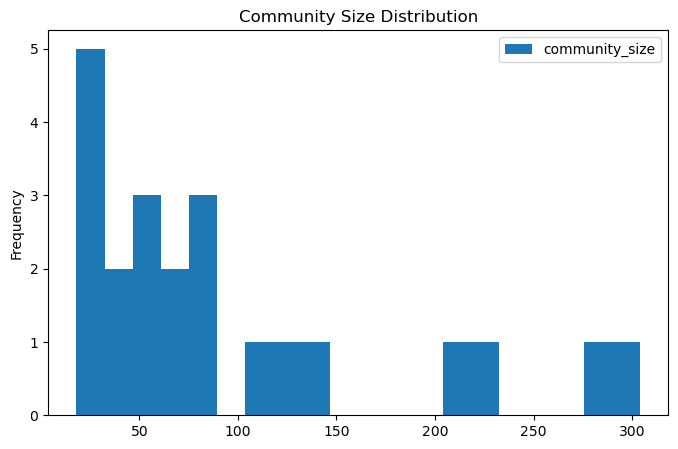

In [52]:
# Annotation: Plot the distribution of Louvain community sizes within the extracted subgraph.
community_sizes = pd.DataFrame([len(community) for community in louvain_communities2rdf], 
                               columns=["community_size"])
community_sizes.plot.hist(bins=20, figsize=(8,5), title="Community Size Distribution");

## 13. Structural characterization of Louvain communities

Each Louvain community is represented as an induced igraph subgraph. The notebook reports node and edge counts, average closeness, mean betweenness, average shortest-path length, and the maximum-betweenness node.

Raw betweenness is size-dependent, so mean values should not be compared across differently sized communities without normalization or an explicit size control.


In [53]:
# Annotation: Create a dictionary that maps each Louvain label to its member-node list.
def get_communities_lists(community_dict):
    communities_lists = {}  # Un diccionario donde las claves son los números de comunidad y los valores son las listas de nodos
    for node, community in community_dict.items():
        if community not in communities_lists:
            communities_lists[community] = []
        communities_lists[community].append(node)
    return communities_lists

# Ejemplo de cómo usar la función para obtener todas las comunidades en diferentes listas
all_communities_lists = get_communities_lists(louvain_communitiesrdf)



In [54]:
# Annotation: Inspect the size of Louvain community 5.
len(all_communities_lists[5])

69

In [55]:
# Annotation: Construct igraph community subgraphs and calculate centrality and path-based statistics.
# Crear un diccionario para almacenar los subgrafos y sus medidas de centralidad
subgrafos_y_centralidad = {}

# Iterar a través de cada comunidad y crear un subgrafo en NetworkX
for comunidad, nodos in all_communities_lists.items():
    subgrafo_nx = G.subgraph(nodos)  # G es tu grafo original de NetworkX
    
    # Convertir el subgrafo de NetworkX a igraph
    subgrafo_ig = ig.Graph(directed=False)
    
    # Agregar nodos con índices únicos para igraph
    node_mapping = {}  # Diccionario para mapear nodos originales a índices en igraph
    for nodo in subgrafo_nx.nodes():
        idx = subgrafo_ig.add_vertex()  # Agregar un nodo en igraph y obtener su índice
        node_mapping[nodo] = idx  # Asociar el nodo original con el índice en igraph
    
    # Agregar aristas con índices únicos
    for edge in subgrafo_nx.edges():
        source = node_mapping[edge[0]]
        target = node_mapping[edge[1]]
        subgrafo_ig.add_edge(source, target)
        
    # Crear el mapeo inverso de índices a URIs
    index_to_uri_mapping = {index: uri for uri, index in node_mapping.items()}
    
    
    closeness=subgrafo_ig.closeness()
    average_closeness = sum(closeness) / subgrafo_ig.vcount()
    centralidad = subgrafo_ig.betweenness()  # Calcular la centralidad que desees
    most_central_node1 = centralidad.index(max(centralidad))
    centralidad = sum(centralidad) / subgrafo_ig.vcount()
    
    for vertex, uri in index_to_uri_mapping.items():
        index_number = int(str(vertex).split()[-2].replace(',',''))
        if index_number==most_central_node1:
            nodouri=uri
    subgrafos_y_centralidad[comunidad] = {
        'subgrafo': subgrafo_ig,
        'centralidad': centralidad,
        'closeness' : average_closeness,
        'nodo central': most_central_node1,
        'uri': nodouri,
        'mapeo':index_to_uri_mapping
    }

# Ahora puedes acceder a los subgrafos y medidas de centralidad por comunidad
for comunidad, data in subgrafos_y_centralidad.items():
    print(f"Comunidad: {comunidad}")
    print("Centralidad:", data['centralidad'])
    print('closeness: ',data['closeness'])
    print("Número de nodos en el subgrafo:", data['subgrafo'].vcount())
    print("Número de enlaces en el subgrafo:", data['subgrafo'].ecount())
    print('Shortest path', data['subgrafo'].average_path_length())
    print('central node',data['nodo central'])
    print('nodo uri',data['uri'])
    print("-----")

Comunidad: 0
Centralidad: 148.8256880733945
closeness:  0.27275036294043153
Número de nodos en el subgrafo: 109
Número de enlaces en el subgrafo: 181
Shortest path 3.7560312606184167
central node 6
nodo uri Femenino
-----
Comunidad: 14
Centralidad: 296.1790393013101
closeness:  0.2836875008765277
Número de nodos en el subgrafo: 229
Número de enlaces en el subgrafo: 372
Shortest path 3.5980617482571056
central node 31
nodo uri http://localhost/ontology2#Lugar
-----
Comunidad: 2
Centralidad: 189.48058252427174
closeness:  0.3620363042910669
Número de nodos en el subgrafo: 206
Número de enlaces en el subgrafo: 606
Shortest path 2.848591049017286
central node 56
nodo uri http://localhost/VENUSTIANO_CARRANZA
-----
Comunidad: 10
Centralidad: 110.26582278481013
closeness:  0.26634777630085116
Número de nodos en el subgrafo: 79
Número de enlaces en el subgrafo: 129
Shortest path 3.8273287893541057
central node 24
nodo uri http://localhost/AGEB128A
-----
Comunidad: 4
Centralidad: 37.38095238095

In [56]:
# Annotation: Collect mean betweenness values by Louvain community.
centralidades=[]
for comunidad, data in subgrafos_y_centralidad.items():
    com= comunidad
    centr= data['centralidad']
    centralidades.append([com,centr])



> **Annotation:** Retain an exploratory heading from the original notebook.

## subgrafos_y_centralidad[0]

In [57]:
# Annotation: Display the mean-betweenness list ordered by community label.
sorted(centralidades)

[[0, 148.8256880733945],
 [1, 56.74468085106382],
 [2, 189.48058252427174],
 [3, 59.8936170212766],
 [4, 37.38095238095237],
 [5, 114.04347826086956],
 [6, 9.0],
 [7, 55.476190476190474],
 [8, 284.50657894736844],
 [9, 12.961538461538463],
 [10, 110.26582278481013],
 [11, 11.545454545454545],
 [12, 165.94262295081964],
 [13, 92.15384615384616],
 [14, 296.1790393013101],
 [15, 10.521739130434783],
 [16, 12.407407407407405],
 [17, 76.45588235294117],
 [18, 55.0408163265306],
 [19, 300.21985815602835],
 [20, 122.67901234567901],
 [21, 169.09722222222217]]

In [58]:
# Annotation: Inspect all nodes assigned to Louvain community 1.
all_communities_lists[1]

['http://localhost/DESARROLLO_URBANO_QUETZALCOATL__III_IZTAPALAPA',
 "(array('d', [-99.0374279669032]), array('d', [19.323186366422]))",
 '4.0',
 'http://localhost/8610577',
 'http://localhost/9223259',
 '30.0',
 'http://localhost/AGEB3401',
 '19.0',
 "(array('d', [-99.0233325280429]), array('d', [19.3446997566282]))",
 '7248',
 "(array('d', [-99.0230241393503]), array('d', [19.3448722464955]))",
 'http://localhost/8728709',
 'http://localhost/AGEB2776',
 "(array('d', [-99.0249518300866]), array('d', [19.3426428406781]))",
 "(array('d', [-99.0396017400065]), array('d', [19.3253911601307]))",
 '140',
 'http://localhost/8681490',
 "(array('d', [-99.0230992418321]), array('d', [19.3448317496798]))",
 'http://localhost/8325473',
 'http://localhost/8785417',
 '209527',
 'http://localhost/8608382',
 "(array('d', [-99.02256]), array('d', [19.34319]))",
 'http://localhost/8784956',
 '7954',
 'http://localhost/CITLALLI_IZTAPALAPA',
 "(array('d', [-99.02345]), array('d', [19.34495]))",
 "(array(

## 14. Reconnect Louvain communities to geographic points

Coordinate-like graph nodes are parsed back into Shapely points. Exact geometry equality is then used to transfer Louvain labels to the DBSCAN point layer. This provides the spatial footprint of communities identified inside the DBSCAN-derived graph substructure.


In [59]:
# Annotation: Define a parser that recovers coordinate points from graph-node strings in every community.
import re
from shapely.geometry import Point

def obtain_coords(dicc):
    rest = {}
    for i, lista in dicc.items():  # Iterar directamente sobre los elementos del diccionario
        # Filtrar elementos que contienen "array"
        list1 = [elemento for elemento in lista if "array" in elemento]
        
        # Extraer valores numéricos y convertirlos en listas de floats
        valores_flotantes = [
            [float(valor) for valor in re.findall(r"-?\d+\.\d+", elemento)]
            for elemento in list1
        ]
        
        # Crear puntos solo si hay exactamente dos coordenadas
        list2 = [Point(coords) for coords in valores_flotantes if len(coords) == 2]
        
        # Asignar los puntos procesados a la clave correspondiente en el resultado
        rest[i] = list2
    return rest


In [60]:
# Annotation: Apply the coordinate parser to all Louvain communities.
coordlist1=obtain_coords(all_communities_lists)

In [61]:
# Annotation: Inspect the coordinate points recovered from community 1.
coordlist1[1]

[<POINT (-99.037 19.323)>,
 <POINT (-99.023 19.345)>,
 <POINT (-99.023 19.345)>,
 <POINT (-99.025 19.343)>,
 <POINT (-99.04 19.325)>,
 <POINT (-99.023 19.345)>,
 <POINT (-99.023 19.343)>,
 <POINT (-99.023 19.345)>,
 <POINT (-99.025 19.342)>,
 <POINT (-99.034 19.326)>,
 <POINT (-99.041 19.324)>,
 <POINT (-99.025 19.345)>,
 <POINT (-99.025 19.345)>,
 <POINT (-99.024 19.341)>,
 <POINT (-99.023 19.342)>]

In [62]:
# Annotation: Define a geometry-matching function that transfers Louvain labels to the point GeoDataFrame.
def define_communities(gdataf, diccionario):
    # Crear una nueva columna para almacenar las comunidades
    gdataf['comunidad'] = None  # Usamos None para valores vacíos
    
    # Iterar sobre el diccionario
    for comunidad, geometries in diccionario.items():
        # Asignar el valor de comunidad si la geometría coincide
        gdataf.loc[gdataf['geometry'].isin(geometries), 'comunidad'] = comunidad
    
    return gdataf

    

In [63]:
# Annotation: Assign Louvain community labels to the selected DBSCAN points.
gdf2=define_communities(gdf1,coordlist1)


In [64]:
# Annotation: List the Louvain communities represented by matched geographic points.
gdf2.comunidad.unique()

array([14, 1, 5, 15, 13, 17, 21, 2, 8, 10, 11, 19, 0, 18, 4, 7, 16, 12,
       20, 3, 6, 9], dtype=object)

<Axes: >

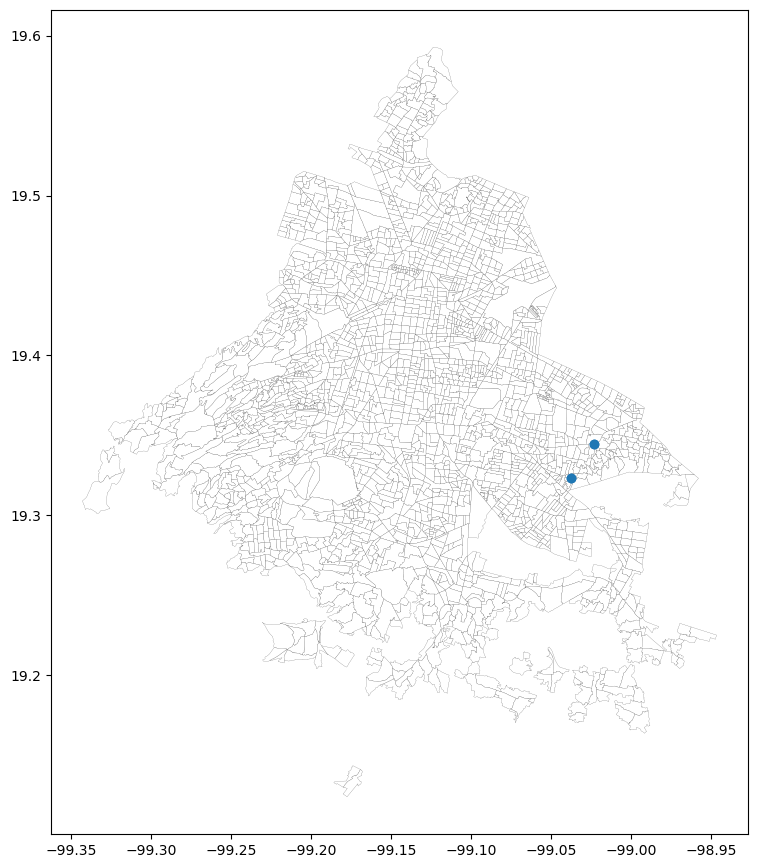

In [65]:
# Annotation: Map the points assigned to Louvain community 1 over the AGEB polygons.
fig,ax=plt.subplots(figsize=(9,11))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.1)
#gdf2.plot(column='comunidad',ax=ax)
gdfcom1=gdf2[gdf2['comunidad']==1]
gdfcom1.plot(ax=ax)

In [66]:
# Annotation: Inspect the geographic records belonging to Louvain community 1.
gdfcom1

,geometry,comunidad
2,POINT (-99.03743 19.32319),1
3,POINT (-99.03743 19.32319),1
39,POINT (-99.02333 19.34470),1
74,POINT (-99.02302 19.34487),1


In [67]:
# Annotation: Inspect ages in the manually selected DBSCAN cluster.
cluster1.Edad

1346    39
1352    24
1376    50
1377    19
1387    29
        ..
2418    37
2424    54
2437    33
2439    48
2608    33
Name: Edad, Length: 92, dtype: int32

In [68]:
# Annotation: Inspect the AGEB poverty polygon layer.
alcal

,CVEGEO,POBREZA,POBREZAEX,ID,geometry
0,0900200010010,"(18, 34]","[ 0, 20]",1,"POLYGON ((-99.20307 19.51415, -99.20319 19.513..."
1,0900200010025,"[ 0, 18]","[ 0, 20]",2,"POLYGON ((-99.19662 19.51270, -99.19662 19.511..."
2,090020001003A,"[ 0, 18]","[ 0, 20]",3,"POLYGON ((-99.20658 19.51169, -99.20611 19.511..."
3,0900200010044,"[ 0, 18]","[ 0, 20]",4,"POLYGON ((-99.20530 19.51033, -99.20529 19.510..."
4,0900200010097,"[ 0, 18]","[ 0, 20]",5,"POLYGON ((-99.20573 19.50454, -99.20630 19.504..."
...,...,...,...,...,...
2427,0901700011488,"(34, 50]","[ 0, 20]",2428,"POLYGON ((-99.05931 19.42789, -99.05934 19.427..."
2428,0901700011492,"(34, 50]","[ 0, 20]",2429,"POLYGON ((-99.05931 19.42789, -99.05794 19.426..."
2429,0901700011505,"[ 0, 18]","[ 0, 20]",2430,"POLYGON ((-99.06102 19.42776, -99.05995 19.426..."
2430,090170001151A,"(18, 34]","[ 0, 20]",2431,"POLYGON ((-99.06253 19.42663, -99.06281 19.426..."


In [69]:
# Annotation: List the poverty-category values present in the polygon layer.
alcal.POBREZA.unique()

array(['(18, 34]', '[ 0, 18]', '(34, 50]', '(50, 70]',
       'Una vivienda particular habitada',
       'Sin viviendas particulares habitadas', '(70, 100]', nan],
      dtype=object)

## 15. Attach AGEB poverty categories

Each mapped point is assigned the poverty category and `CVEGEO` of its containing AGEB polygon. This nested loop is equivalent to a spatial join but is less efficient. `GeoPandas.sjoin` would provide a clearer and faster implementation for the final replication package.


In [70]:
# Annotation: Assign each matched point the poverty category and CVEGEO of its containing AGEB polygon.
gdf2['pobreza']=''
gdf2['CVE']=''
for i in range(0,len(alcal)):
    geom=alcal.geometry.iloc[i]
    pobre=alcal.POBREZA.iloc[i]
    cve=alcal.CVEGEO.iloc[i]
    for j in range(0,len(gdf2)):
        punto=gdf2.geometry.iloc[j]
        if geom.contains(punto):
            gdf2.loc[gdf2['geometry']==punto,'pobreza']= pobre
            gdf2.loc[gdf2['geometry']==punto,'CVE']= cve

In [71]:
# Annotation: Inspect the geographically enriched point layer.
gdf2

,geometry,comunidad,pobreza,CVE
0,POINT (-99.09567 19.44899),14,"(18, 34]",0901700010085
1,POINT (-99.20216 19.34753),14,"[ 0, 18]",090100001110A
2,POINT (-99.03743 19.32319),1,"(34, 50]",0900700013401
3,POINT (-99.03743 19.32319),1,"(34, 50]",0900700013401
4,POINT (-99.24480 19.32462),5,"(18, 34]",0900800010103
...,...,...,...,...
87,POINT (-99.15521 19.45800),20,"(34, 50]",0901500010042
88,POINT (-99.24247 19.31966),5,"(18, 34]",0900800010211
89,POINT (-99.04305 19.31501),9,"(34, 50]",0900700015380
90,POINT (-99.12398 19.37947),20,"[ 0, 18]",0900600010984


> **Annotation:** Mark the beginning of the revised spatial-grouping procedure.

# Nueva forma de agregar

In [398]:
# Annotation: Count the poverty categories assigned to mapped points.
gdf2['pobreza'].value_counts()

pobreza
[ 0, 18]                            13
(18, 34]                             9
(34, 50]                             7
                                     2
Una vivienda particular habitada     1
Name: count, dtype: int64

## 16. Geodesic distance matrix

Pairwise geodesic distances between mapped points are calculated in kilometres. Here the matrix labels and `IDS` both use the GeoDataFrame index, so the later `.loc` operations are internally aligned.


In [451]:
# Annotation: Compute the complete pairwise geodesic-distance matrix in kilometres.
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from geopy.distance import geodesic


def geod_distance(p1, p2):
    return geodesic((p1.y, p1.x), (p2.y, p2.x)).kilometers

# Calcular la matriz de distancias geodésicas
dist_matrix_geod = [
    [geod_distance(p1, p2) for p2 in gdf2['geometry']]
    for p1 in gdf2['geometry']
]

# Convertir la matriz a un DataFrame
dist_matrix_df = pd.DataFrame(dist_matrix_geod, index=gdf2.index, columns=gdf2.index)

dist_matrix_df


,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,0.000000,6.463007,3.914168,21.044985,6.651089,14.257890,6.778152,12.208786,11.950879,13.041234,...,13.571803,18.018637,5.757659,12.527086,23.162855,18.955518,14.012967,1.869848,4.001218,3.637349
1,6.463007,0.000000,3.211945,16.231936,9.026638,8.222490,6.984691,6.254823,5.507627,7.509610,...,7.840733,15.127451,5.250444,6.783708,19.154740,13.612403,8.361435,7.428435,9.571589,8.121585
2,3.914168,3.211945,0.000000,17.257256,8.765993,10.380920,4.620387,9.459147,8.582806,9.127170,...,9.661203,14.817789,5.934014,8.620469,19.609552,15.067173,10.099141,4.390867,7.700983,4.912441
3,21.044985,16.231936,17.257256,0.000000,25.256236,9.055820,15.394333,16.514120,13.885715,8.820133,...,8.716692,6.858875,21.435882,9.661705,4.221688,3.298031,8.158546,20.757089,24.952573,19.961775
4,6.651089,9.026638,8.765993,25.256236,0.000000,17.001811,12.989780,11.848380,13.049325,16.519529,...,16.798559,23.549257,3.977136,15.758043,28.057136,22.608259,17.335068,8.421582,4.677716,10.249280
5,14.257890,8.222490,10.380920,9.055820,17.001811,0.000000,10.944263,7.484721,4.829904,2.078689,...,1.325787,11.122676,13.040835,1.943000,12.824547,5.924285,1.522773,14.652996,17.733384,14.579246
6,6.778152,6.984691,4.620387,15.394333,12.989780,10.944263,0.000000,12.851585,11.161540,9.072966,...,9.807631,11.399030,10.534368,9.002981,16.874298,13.987625,10.040807,5.774911,10.699152,4.617645
7,12.208786,6.254823,9.459147,16.514120,11.848380,7.484721,12.851585,0.000000,2.737596,8.413367,...,8.142437,17.934989,8.144360,7.536770,20.299833,13.301687,8.654720,13.491784,14.357757,14.352134
8,11.950879,5.507627,8.582806,13.885715,13.049325,4.829904,11.161540,2.737596,0.000000,5.678681,...,5.409876,15.225987,9.105269,4.807511,17.601168,10.726702,5.928625,12.914665,14.747066,13.445165
9,13.041234,7.509610,9.127170,8.820133,16.519529,2.078689,9.072966,8.413367,5.678681,0.000000,...,0.771513,9.593305,12.646040,0.897932,12.155704,6.104989,0.999484,13.221769,16.720450,12.961920


In [452]:
# Annotation: Copy the GeoDataFrame index into an explicit IDS field used by the distance matrix.

gdf2['IDS']=gdf2.index.values
gdf2

,geometry,comunidad,pobreza,CVE,IDS
0,POINT (-99.13220 19.47588),4,"[ 0, 18]",0900500011561,0
1,POINT (-99.14124 19.41813),9,"[ 0, 18]",0901500011144,1
2,POINT (-99.12321 19.44157),9,"(34, 50]",0901500010589,2
3,POINT (-99.04081 19.30670),0,"(34, 50]",090110001122A,3
4,POINT (-99.19527 19.48155),6,"(18, 34]",0900200011023,4
5,POINT (-99.11514 19.34810),8,"[ 0, 18]",0900700011354,5
6,POINT (-99.07921 19.44091),7,"(18, 34]",0901700010352,6
7,POINT (-99.18028 19.37547),3,"[ 0, 18]",0901400010702,7
8,POINT (-99.15485 19.37008),3,"[ 0, 18]",0901400010774,8
9,POINT (-99.10152 19.36172),3,"(34, 50]",0900700010731,9


## 17. Select a seed from the largest Louvain community

The function identifies the most populated Louvain community and selects the point with the smallest mean distance to other members. Using `groupby().size().idxmax()` would express the intended selection more directly than taking the maximum across every counted column.


In [458]:
# Annotation: Define a function that selects the most central point in the most populated Louvain community.
import numpy as np

def find_central_point_by_community(gdf, dist_matrix_df):
    """
    Encuentra el punto central en la comunidad con el número máximo de elementos
    considerando una matriz de distancias.
    
    Args:
    - gdf (GeoDataFrame): GeoDataFrame con una columna 'comunidad' que agrupa los puntos.
    - dist_matrix_df (DataFrame): Matriz de distancias entre los índices de gdf.

    Returns:
    - central_point (list): [índice del punto central, comunidad asociada].
    """
    # Agrupar por 'comunidad' y contar el número de elementos por comunidad
    groups = gdf.groupby('comunidad').count()

    # Encontrar el valor máximo y su índice correspondiente
    max_count = groups.max().max()  # Obtiene el valor máximo global
    max_group = groups[groups == max_count].dropna()  # Filtra las filas correspondientes al valor máximo
    indices = max_group.index.values  # Obtener los índices de comunidades con el valor máximo
    print("Índices con el valor máximo:", indices)

    # Inicializar variables para encontrar el punto central
    min_avg_distance = np.inf
    central_point = None

    # Iterar sobre los índices de las comunidades con el máximo valor
    for i in indices:
        # Filtrar los datos correspondientes a la comunidad actual
        dat = gdf[gdf['comunidad'] == i]
        identifi = dat.index.values.tolist()  # Obtener los identificadores de los puntos

        # Calcular la distancia promedio para cada punto en esta comunidad
        for k in range(len(identifi)):
            ind1 = identifi[k]
            avg_distance = np.mean(
                [dist_matrix_df.loc[ind1, identifi[j]] for j in range(len(identifi)) if k != j]
            )
            # Actualizar el punto central si la distancia promedio es menor
            if avg_distance < min_avg_distance:
                min_avg_distance = avg_distance
                central_point = [ind1, i]

    return central_point


In [459]:
# Annotation: Apply the seed-selection function and inspect the selected point.
central_point = find_central_point_by_community(gdf2, dist_matrix_df)
print("Punto central:", central_point)

# Acceder a las coordenadas o datos del punto central
if central_point:
    print("Datos del punto central:")
    print(gdf2.loc[central_point[0]])


Índices con el valor máximo: [1]
Punto central: [25, 1]
Datos del punto central:
geometry     POINT (-99.1094280002496 19.3647981566062)
comunidad                                             1
pobreza                                        [ 0, 18]
CVE                                       0900700010727
IDS                                                  25
Name: 25, dtype: object


In [461]:
# Annotation: Load an additional population shapefile used by an earlier exploratory branch.
poblacion=gpd.read_file('total.shp')

ERROR:fiona._env:PROJ: proj_identify: C:\Program Files\PostgreSQL\13\share\contrib\postgis-3.1\proj\proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR:fiona._env:PROJ: proj_identify: C:\Program Files\PostgreSQL\13\share\contrib\postgis-3.1\proj\proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.


In [462]:
# Annotation: Derive a four-character AGEB suffix in the population layer.
poblacion['ageb']=poblacion.ageb.str[-4:]

In [463]:
# Annotation: Inspect the population-layer attributes.
poblacion.head()

,alc,loc,amb_loc,ageb,pob,p_3ymas,p_12yms,p_nacoe,p_vivoe,p_hli,...,t_hli_h,t_afrmx,t_p12ym_sl,t_p12ym_c,t_p12ym_sp,t_catlc,t_criev,t_trsrl,t_sinrl,geometry
0,Álvaro Obregón,Álvaro Obregón,Urbana,1716,7042.0,6811.0,5896.0,1420.0,134.0,170.0,...,2.451916,0.908833,34.107870,50.661465,15.213704,79.011644,6.617438,0.085203,14.257313,"POLYGON ((-99.25882 19.32558, -99.25834 19.325..."
1,Álvaro Obregón,Álvaro Obregón,Urbana,2150,4588.0,4487.0,4062.0,672.0,142.0,26.0,...,0.579452,1.307759,39.217134,44.780896,15.952733,79.707934,5.732345,0.566696,13.949433,"POLYGON ((-99.19170 19.37893, -99.19170 19.378..."
2,Álvaro Obregón,Álvaro Obregón,Urbana,1133,2203.0,2179.0,2025.0,473.0,119.0,25.0,...,1.101423,1.497957,39.111111,43.407407,16.049383,67.362687,5.991829,0.862460,24.148888,"POLYGON ((-99.17760 19.35182, -99.17766 19.351..."
3,Álvaro Obregón,Álvaro Obregón,Urbana,1307,2914.0,2859.0,2628.0,657.0,175.0,86.0,...,2.973068,0.754976,41.400304,48.439878,9.931507,84.179822,3.294441,0.411805,11.873713,"POLYGON ((-99.20805 19.31277, -99.20768 19.312..."
4,Álvaro Obregón,Álvaro Obregón,Urbana,0281,237.0,234.0,204.0,53.0,23.0,6.0,...,2.564103,2.531646,39.705882,48.529412,11.274510,81.012658,NaN,2.953586,14.767932,"POLYGON ((-99.24228 19.38451, -99.24233 19.384..."


In [490]:
# Annotation: Use the global mean pairwise distance as the spatial expansion threshold.
mean_distance = dist_matrix_df.values.mean()
print("Media general:", mean_distance)

Media general: 11.934640241806836


In [466]:
# Annotation: Retain a disabled calculation of population-based bounds from an earlier version.
#mean_pob = poblacion.pob.mean()
#std_pob =poblacion.pob.std()

###lim_inf_pob = mean_pob - std_pob
###lim_sup_pob = mean_pob + std_pob

In [467]:
# Annotation: Retain a disabled attempt to attach population counts to candidate points.
"""dftest1['poblacion']=''
for i in range(0,len(dftest1)):
    row=dftest1.iloc[i]
    ag=row['ageb']
    pop=poblacion[poblacion['ageb']==ag]
    if len(pop) > 0:
        dftest1['poblacion'].iloc[i]=pop['pob'].values[0]
    else:
        dftest1['poblacion'].iloc[i]=0"""

"dftest1['poblacion']=''\nfor i in range(0,len(dftest1)):\n    row=dftest1.iloc[i]\n    ag=row['ageb']\n    pop=poblacion[poblacion['ageb']==ag]\n    if len(pop) > 0:\n        dftest1['poblacion'].iloc[i]=pop['pob'].values[0]\n    else:\n        dftest1['poblacion'].iloc[i]=0"

In [470]:
# Annotation: Display the selected central point and its Louvain community.
central_point

[25, 1]

## 18. Exploratory distance- and poverty-constrained grouping

The selected seed and its entire Louvain community initialize a spatial group. Remaining points are added when they share a poverty category with a current member and lie within the global mean pairwise distance. Because newly added points can admit further candidates, this produces a chain-expansion effect similar to single linkage.

The initial root is concatenated with a community subset that already contains it, so the root may be duplicated in `grupo` unless duplicates are removed.


<Axes: >

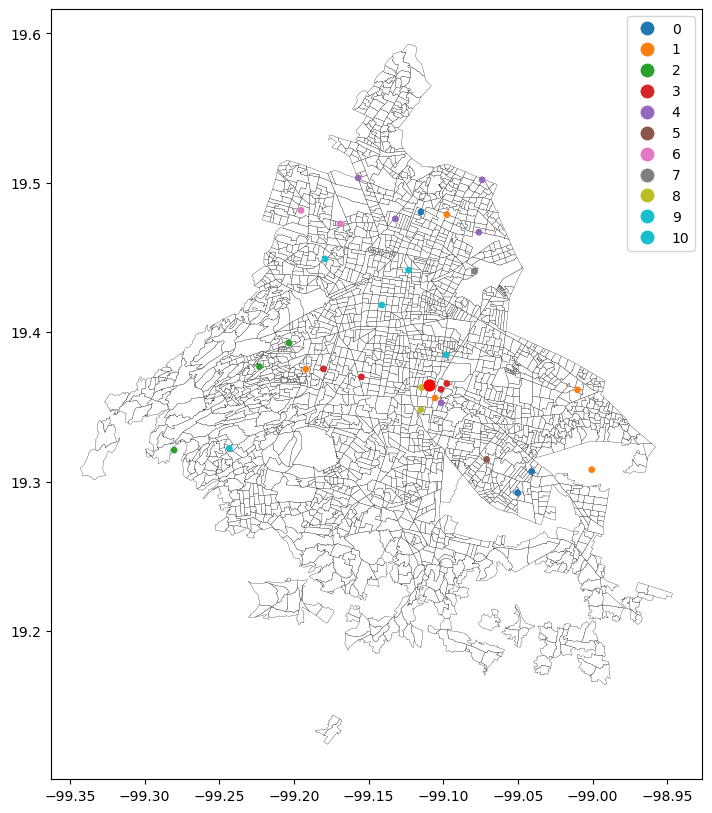

In [471]:
# Annotation: Map the selected root point over all mapped Louvain-community points.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
root=gdf2[gdf2['IDS']==central_point[0]]
#root=root[root['comunidad']==central_points[0]]
gdf2.plot(ax=ax,column='comunidad',markersize=15,legend=True,categorical=True)
root.plot(ax=ax,markersize=60,color='red')


In [503]:
# Annotation: Initialize the first exploratory spatial group from the selected root.
grupo=gpd.GeoDataFrame(root,geometry=root.geometry)
grupo.columns

Index(['geometry', 'comunidad', 'pobreza', 'CVE', 'IDS'], dtype='object')

In [504]:
# Annotation: Add all members of the root's Louvain community to the initial group.
grupo = pd.concat([grupo, gdf2[gdf2['comunidad'] == central_point[1]]])
grupo

,geometry,comunidad,pobreza,CVE,IDS
25,POINT (-99.10943 19.36480),1,"[ 0, 18]",0900700010727,25
13,POINT (-99.19214 19.37526),1,"[ 0, 18]",0901000010525,13
22,POINT (-99.10557 19.35591),1,"(34, 50]",0900700011208,22
23,POINT (-99.01021 19.36143),1,"(34, 50]",090070001084A,23
25,POINT (-99.10943 19.36480),1,"[ 0, 18]",0900700010727,25
26,POINT (-99.00066 19.30794),1,,,26
31,POINT (-99.09769 19.47876),1,"[ 0, 18]",0900500011650,31


In [505]:
# Annotation: Remove the selected Louvain community from the candidate set.
gdf3=gdf2[gdf2['comunidad'] != central_point[1]]
gdf3
#dftest2

,geometry,comunidad,pobreza,CVE,IDS
0,POINT (-99.13220 19.47588),4,"[ 0, 18]",0900500011561,0
1,POINT (-99.14124 19.41813),9,"[ 0, 18]",0901500011144,1
2,POINT (-99.12321 19.44157),9,"(34, 50]",0901500010589,2
3,POINT (-99.04081 19.30670),0,"(34, 50]",090110001122A,3
4,POINT (-99.19527 19.48155),6,"(18, 34]",0900200011023,4
5,POINT (-99.11514 19.34810),8,"[ 0, 18]",0900700011354,5
6,POINT (-99.07921 19.44091),7,"(18, 34]",0901700010352,6
7,POINT (-99.18028 19.37547),3,"[ 0, 18]",0901400010702,7
8,POINT (-99.15485 19.37008),3,"[ 0, 18]",0901400010774,8
9,POINT (-99.10152 19.36172),3,"(34, 50]",0900700010731,9


In [506]:
# Annotation: Store the modal poverty category of the initial group.
listapobreza=[]
listapobreza.extend(grupo['pobreza'].mode())

In [507]:
# Annotation: Display the stored poverty-category list.
listapobreza

['[ 0, 18]']

In [508]:
# Annotation: Expand group 1 using equal poverty and the global mean-distance threshold.
import pandas as pd

# Supongamos que tienes los DataFrames dftest2 y grupo, y la matriz de distancias dist_matrix_df ya definidos
# También asumiendo que lim_inf_pob, lim_sup_pob, y mean_distance ya están definidos

# Inicializa la columna 'pop_range' en dftest2
#dftest2['pop_range'] = ''

# Itera sobre las filas de dftest2
dftest2=gdf3.copy()
for i in range(len(dftest2)):
    row2 = dftest2.iloc[i]
    ind2 = row2['IDS']
    #pob2 = row2['poblacion']
    rangpob2 = row2['pobreza']
    
    for j in range(len(grupo)):
        row1 = grupo.iloc[j]
        ind1 = row1['IDS']
        #pob1 = row1['poblacion']
        rangpob = row1['pobreza']
        
        distance_value = dist_matrix_df.loc[ind1, ind2]
        if (distance_value <= mean_distance) and (rangpob == rangpob2):

            grupo = pd.concat([grupo, pd.DataFrame([row2])], ignore_index=True)
            break  # Salir del bucle interno después de agregar la fila

print(grupo)



                      geometry comunidad   pobreza            CVE  IDS
0   POINT (-99.10943 19.36480)         1  [ 0, 18]  0900700010727   25
1   POINT (-99.19214 19.37526)         1  [ 0, 18]  0901000010525   13
2   POINT (-99.10557 19.35591)         1  (34, 50]  0900700011208   22
3   POINT (-99.01021 19.36143)         1  (34, 50]  090070001084A   23
4   POINT (-99.10943 19.36480)         1  [ 0, 18]  0900700010727   25
5   POINT (-99.00066 19.30794)         1                            26
6   POINT (-99.09769 19.47876)         1  [ 0, 18]  0900500011650   31
7   POINT (-99.13220 19.47588)         4  [ 0, 18]  0900500011561    0
8   POINT (-99.14124 19.41813)         9  [ 0, 18]  0901500011144    1
9   POINT (-99.12321 19.44157)         9  (34, 50]  0901500010589    2
10  POINT (-99.04081 19.30670)         0  (34, 50]  090110001122A    3
11  POINT (-99.11514 19.34810)         8  [ 0, 18]  0900700011354    5
12  POINT (-99.18028 19.37547)         3  [ 0, 18]  0901400010702    7
13  PO

In [509]:
# Annotation: Inspect poverty categories represented in the expanded first group.
grupo['pobreza'].unique().tolist()

['[ 0, 18]', '(34, 50]', '']

In [510]:
# Annotation: Store first-group identifiers and report its size.
listaids=grupo['IDS'].values.tolist()
len(grupo)

22

In [511]:
# Annotation: Remove first-group members from the remaining candidate points.
dftest3 = dftest2[~dftest2['IDS'].isin(listaids)]
dftest3['pobreza'].unique()

array(['(18, 34]', 'Una vivienda particular habitada', ''], dtype=object)

In [512]:
# Annotation: Report the number of unassigned points after constructing group 1.
len(dftest3)

11

<Axes: >

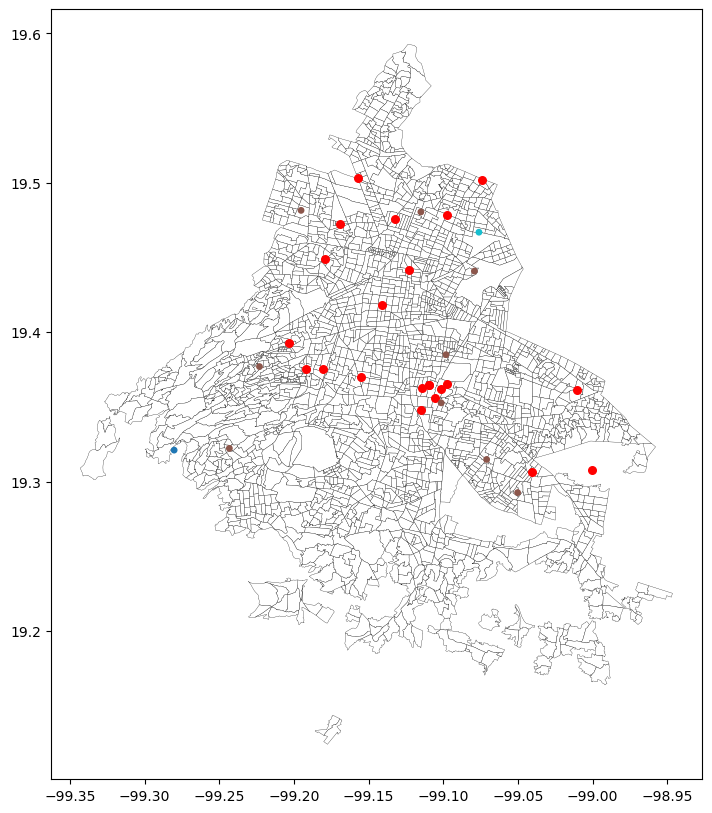

In [515]:
# Annotation: Map group 1 together with the remaining points colored by poverty category.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
grupo.plot(ax=ax,markersize=30,color='red')

dftest3.plot(ax=ax,column='pobreza',markersize=15,categorical=True)

In [516]:
# Annotation: Assign label 1 to the first exploratory group.
grupo['newgroup']=1

In [521]:
# Annotation: Inspect the polygon layer before transferring group labels.
alcal

,CVEGEO,POBREZA,POBREZAEX,ID,geometry,cluster
0,0900200010010,"(18, 34]","[ 0, 20]",1,"POLYGON ((-99.20307 19.51415, -99.20319 19.513...",
1,0900200010025,"[ 0, 18]","[ 0, 20]",2,"POLYGON ((-99.19662 19.51270, -99.19662 19.511...",
2,090020001003A,"[ 0, 18]","[ 0, 20]",3,"POLYGON ((-99.20658 19.51169, -99.20611 19.511...",
3,0900200010044,"[ 0, 18]","[ 0, 20]",4,"POLYGON ((-99.20530 19.51033, -99.20529 19.510...",
4,0900200010097,"[ 0, 18]","[ 0, 20]",5,"POLYGON ((-99.20573 19.50454, -99.20630 19.504...",
...,...,...,...,...,...,...
2427,0901700011488,"(34, 50]","[ 0, 20]",2428,"POLYGON ((-99.05931 19.42789, -99.05934 19.427...",
2428,0901700011492,"(34, 50]","[ 0, 20]",2429,"POLYGON ((-99.05931 19.42789, -99.05794 19.426...",
2429,0901700011505,"[ 0, 18]","[ 0, 20]",2430,"POLYGON ((-99.06102 19.42776, -99.05995 19.426...",
2430,090170001151A,"(18, 34]","[ 0, 20]",2431,"POLYGON ((-99.06253 19.42663, -99.06281 19.426...",


## 19. Transfer group 1 to AGEB polygons

The first exploratory group receives label `1`, and its incident-level assignments are propagated to matching AGEB polygons for cartographic display. If an AGEB occurs more than once with conflicting labels, `list.index` retains the first match.


In [525]:
# Annotation: Create the AGEB polygon layer associated with exploratory group 1.
# Crear un DataFrame vacío para almacenar los resultados
alcgrupo1 = gpd.GeoDataFrame()

# Lista de IDs de ageb y valores de cluster de grupo
agsgru = grupo.CVE.values.tolist()
lista_cluster = grupo.newgroup.values.tolist()
alcal['cluster']=''
# Asignar el valor del cluster a alcshp
filas_a_agregar = []
for i in range(len(alcal)):
    row2 = alcal.iloc[i]
    if row2.CVEGEO in agsgru:
        # Obtener el valor del cluster correspondiente a la ageb de alcshp
        cluster_value = lista_cluster[agsgru.index(row2.CVEGEO)]
        # Asignar el valor del cluster a la columna 'cluster' en alcshp
        row2['cluster'] = cluster_value
        # Agregar la fila a la lista de filas a agregar
        filas_a_agregar.append(row2)

# Concatenar las filas a agregar al DataFrame alcgrupo1
alcgrupo1 = pd.concat([alcgrupo1, pd.DataFrame(filas_a_agregar)], ignore_index=True)

# Mostrar el resultado
alcgrupo1=gpd.GeoDataFrame(alcgrupo1,geometry=alcgrupo1.geometry)

C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_23072\1894859619.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  row2['cluster'] = cluster_value


In [527]:
# Annotation: Count AGEB polygons assigned to group 1.
alcgrupo1.cluster.value_counts()

cluster
1    19
Name: count, dtype: int64

In [533]:
# Annotation: Inspect the group-1 polygon GeoDataFrame.
alcgrupo1

,CVEGEO,POBREZA,POBREZAEX,ID,geometry,cluster
0,0900200011131,"[ 0, 18]","[ 0, 20]",98,"POLYGON ((-99.16443 19.47446, -99.16374 19.472...",1
1,0900500010493,"[ 0, 18]","[ 0, 20]",329,"POLYGON ((-99.15836 19.50592, -99.15725 19.506...",1
2,090050001085A,"(34, 50]","[ 0, 20]",358,"POLYGON ((-99.07790 19.50420, -99.07747 19.504...",1
3,0900500011561,"[ 0, 18]","[ 0, 20]",426,"POLYGON ((-99.13107 19.47275, -99.13143 19.471...",1
4,0900500011650,"[ 0, 18]","[ 0, 20]",435,"POLYGON ((-99.09388 19.47742, -99.09317 19.477...",1
5,0900700010727,"[ 0, 18]","[ 0, 20]",765,"POLYGON ((-99.10912 19.36673, -99.10905 19.367...",1
6,0900700010731,"(34, 50]","[ 0, 20]",766,"POLYGON ((-99.10061 19.36845, -99.09993 19.368...",1
7,090070001084A,"(34, 50]","[ 0, 20]",776,"POLYGON ((-99.00768 19.35836, -99.00787 19.358...",1
8,0900700010943,"[ 0, 18]","[ 0, 20]",784,"POLYGON ((-99.11777 19.36132, -99.11733 19.363...",1
9,0900700011208,"(34, 50]","[ 0, 20]",804,"POLYGON ((-99.10176 19.35449, -99.10179 19.354...",1


In [534]:
# Annotation: Propagate group-1 labels back to the complete AGEB polygon layer.
# Crear una columna 'cluster' en alcshp
alcal['cluster'] = ''

# Iterar sobre cada fila de alcgrupo1
for i in range(len(alcgrupo1)):
    row = alcgrupo1.iloc[i]
    ageb = row['CVEGEO']
    cluster_value = row['cluster']
    
    # Buscar la fila correspondiente en alcshp y asignar el valor del cluster
    alcal.loc[alcal['CVEGEO'] == ageb, 'cluster'] = cluster_value


<Axes: >

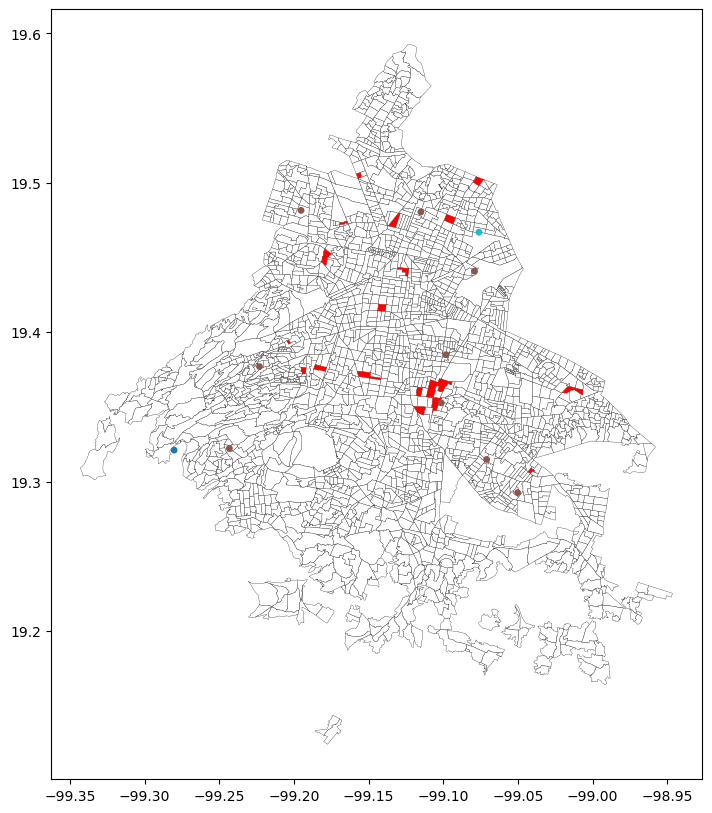

In [539]:
# Annotation: Visualize group-1 polygons and points still awaiting assignment.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
alcgrupo1.plot(ax=ax,color='red')

dftest3.plot(ax=ax,column='pobreza',markersize=15,categorical=True)

In [536]:
# Annotation: Inspect the columns retained in the current incident-level group table.
grupo.columns

Index(['geometry', 'comunidad', 'pobreza', 'CVE', 'IDS', 'newgroup'], dtype='object')

In [540]:
# Annotation: Count poverty categories among the points remaining after group 1.
dftest3['pobreza'].value_counts()

pobreza
(18, 34]                            9
Una vivienda particular habitada    1
                                    1
Name: count, dtype: int64

## 20. Construct the second exploratory group

After removing group 1, the seed-selection and expansion procedure is repeated for the remaining points. This manual repetition should be converted into a loop or function if the spatial grouping is retained in the final method.


In [541]:
# Annotation: Select the next central point from the remaining candidates.
central_point = find_central_point_by_community(dftest3, dist_matrix_df)
print("Punto central:", central_point)

# Acceder a las coordenadas o datos del punto central
if central_point:
    print("Datos del punto central:")
    print(gdf2.loc[central_point[0]])

Índices con el valor máximo: [ 0  2  4 10]
Punto central: [14, 2]
Datos del punto central:
geometry     POINT (-99.2231064995787 19.3769647909183)
comunidad                                             2
pobreza                                        (18, 34]
CVE                                       0901000011947
IDS                                                  14
Name: 14, dtype: object


In [542]:
# Annotation: Initialize group 2 from the selected central point.
root=dftest3[dftest3['IDS']==central_point[0]]
root

,geometry,comunidad,pobreza,CVE,IDS
14,POINT (-99.22311 19.37696),2,"(18, 34]",0901000011947,14


<Axes: >

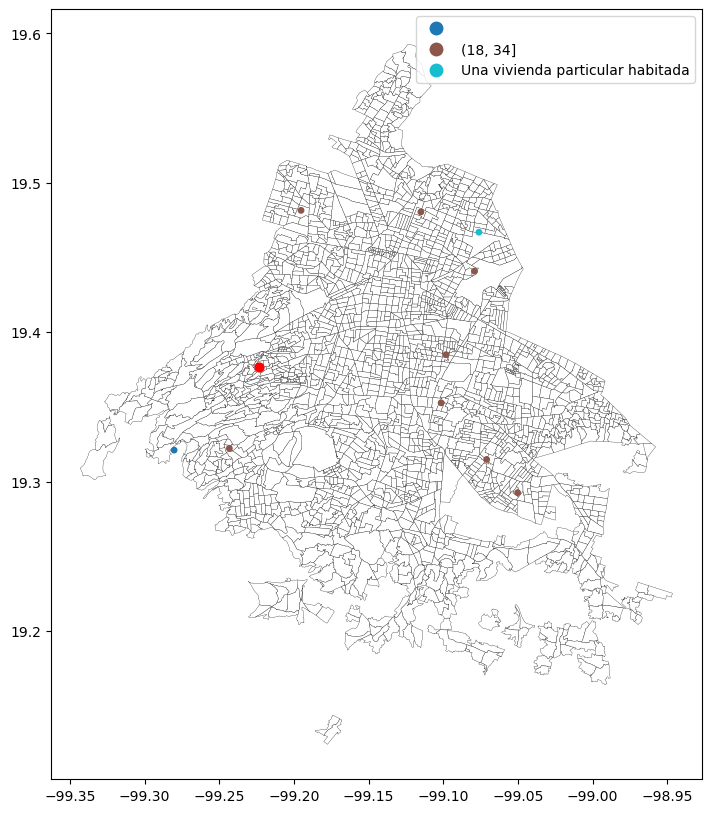

In [543]:
# Annotation: Map the second root over the remaining candidate points.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
dftest3.plot(ax=ax,column='pobreza',markersize=15,legend=True,categorical=True)
root.plot(ax=ax,markersize=40,color='red')


In [544]:
# Annotation: Create the second group GeoDataFrame from its root point.
grupo=gpd.GeoDataFrame(root,geometry=root.geometry)
grupo.columns

Index(['geometry', 'comunidad', 'pobreza', 'CVE', 'IDS'], dtype='object')

In [545]:
# Annotation: Inspect the poverty category of the second root.
grupo['pobreza']

14    (18, 34]
Name: pobreza, dtype: object

In [547]:
# Annotation: Display the previously stored poverty-category list for comparison.
listapobreza

['[ 0, 18]', '(18, 34]']

In [549]:
# Annotation: Remove the second root from the candidate set before expansion.
dftest4=dftest3[dftest3['IDS'] != central_point[0]]
dftest4

,geometry,comunidad,pobreza,CVE,IDS
4,POINT (-99.19527 19.48155),6,"(18, 34]",0900200011023,4
6,POINT (-99.07921 19.44091),7,"(18, 34]",0901700010352,6
10,POINT (-99.07618 19.46693),4,Una vivienda particular habitada,0900500012165,10
11,POINT (-99.05028 19.29259),0,"(18, 34]",0901100010645,11
17,POINT (-99.28024 19.32103),2,,,17
19,POINT (-99.09824 19.38494),10,"(18, 34]",0900600011130,19
20,POINT (-99.24328 19.32222),10,"(18, 34]",0900800010141,20
27,POINT (-99.07101 19.31479),5,"(18, 34]",090070001198A,27
28,POINT (-99.10147 19.35270),4,"(18, 34]",0900700013740,28
29,POINT (-99.11506 19.48047),0,"(18, 34]",0900500011449,29


In [550]:
# Annotation: Expand group 2 using equal poverty and the global mean-distance threshold.
import pandas as pd

# Supongamos que tienes los DataFrames dftest2 y grupo, y la matriz de distancias dist_matrix_df ya definidos
# También asumiendo que lim_inf_pob, lim_sup_pob, y mean_distance ya están definidos


# Itera sobre las filas de dftest2
for i in range(len(dftest4)):
    row2 = dftest4.iloc[i]
    ind2 = row2['IDS']
    #pob2 = row2['poblacion']
    rangpob2 = row2['pobreza']
    
    for j in range(len(grupo)):
        row1 = grupo.iloc[j]
        ind1 = row1['IDS']
        #pob1 = row1['poblacion']
        rangpob = row1['pobreza']
        
        distance_value = dist_matrix_df.loc[ind1, ind2]
        if (distance_value <= mean_distance) and (rangpob == rangpob2):
            
            grupo = pd.concat([grupo, pd.DataFrame([row2])], ignore_index=True)
            break  # Salir del bucle interno después de agregar la fila

print(grupo)



                     geometry comunidad   pobreza            CVE  IDS
0  POINT (-99.22311 19.37696)         2  (18, 34]  0901000011947   14
1  POINT (-99.24328 19.32222)        10  (18, 34]  0900800010141   20


In [551]:
# Annotation: Inspect poverty categories represented in the expanded second group.
grupo['pobreza'].unique()

array(['(18, 34]'], dtype=object)

In [552]:
# Annotation: Store second-group identifiers and report its size.
listaids=grupo['IDS'].values.tolist()
len(grupo)

2

In [553]:
# Annotation: Remove second-group members from the remaining candidate points.
dftest5 = dftest4[~dftest4['IDS'].isin(listaids)]
dftest5['pobreza'].unique()

array(['(18, 34]', 'Una vivienda particular habitada', ''], dtype=object)

In [554]:
# Annotation: Report the final size of group 2.
len(grupo)

2

<Axes: >

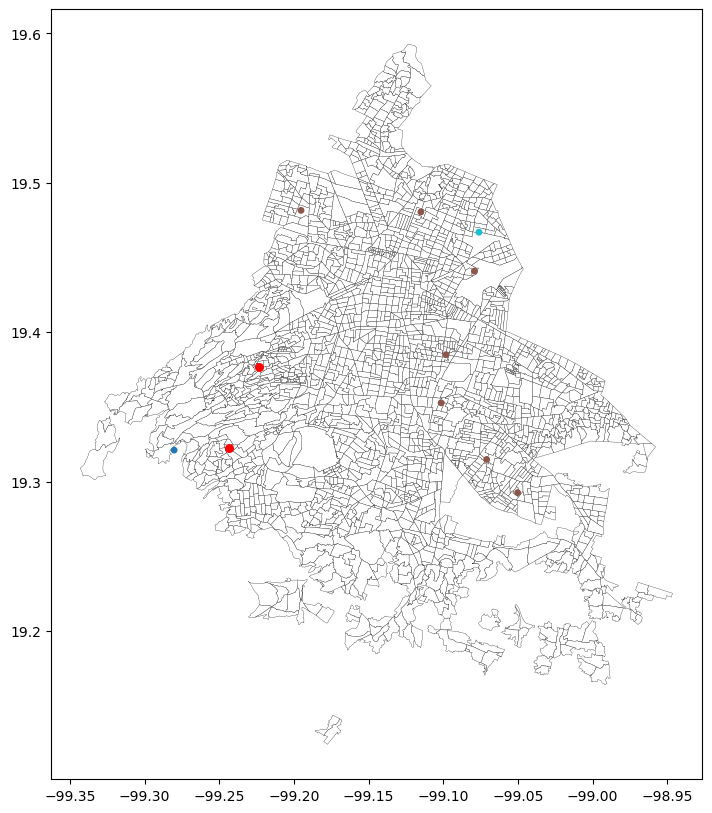

In [555]:
# Annotation: Map group 2 and the remaining unassigned points.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
grupo.plot(ax=ax,markersize=30,color='red')

dftest5.plot(ax=ax,column='pobreza',markersize=15,categorical=True)

In [557]:
# Annotation: Assign label 2 to the second exploratory group.
grupo['newgroup']=2

## 21. Transfer group 2 to AGEB polygons

The second group is converted into an AGEB polygon layer. The following legacy cell refers to `alcshp`, which is not defined in the executable path, and uses `CVE_AGEB` rather than the `CVEGEO` field used elsewhere. It is retained for provenance but should not be included in a clean execution path.


In [559]:
# Annotation: Create the AGEB polygon layer associated with exploratory group 2.
# Crear un DataFrame vacío para almacenar los resultados
alcgrupo2 = gpd.GeoDataFrame()

# Lista de IDs de ageb y valores de cluster de grupo
agsgru = grupo.CVE.values.tolist()
lista_cluster = grupo.newgroup.values.tolist()

# Asignar el valor del cluster a alcshp
filas_a_agregar = []
for i in range(len(alcal)):
    row2 = alcal.iloc[i]
    if row2.CVEGEO in agsgru:
        # Obtener el valor del cluster correspondiente a la ageb de alcshp
        cluster_value = lista_cluster[agsgru.index(row2.CVEGEO)]
        # Asignar el valor del cluster a la columna 'cluster' en alcshp
        row2['cluster'] = cluster_value
        # Agregar la fila a la lista de filas a agregar
        filas_a_agregar.append(row2)

# Concatenar las filas a agregar al DataFrame alcgrupo1
alcgrupo2 = pd.concat([alcgrupo2, pd.DataFrame(filas_a_agregar)], ignore_index=True)

# Mostrar el resultado
alcgrupo2=gpd.GeoDataFrame(alcgrupo2,geometry=alcgrupo2.geometry)

C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_23072\2417436692.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  row2['cluster'] = cluster_value


In [2069]:
# Annotation: Attempt to propagate polygon labels through an undefined legacy `alcshp` object.
# Crear una columna 'cluster' en alcshp
alcshp['cluster'] = ''

# Iterar sobre cada fila de alcgrupo1
for i in range(len(alcgrupo1)):
    row = alcgrupo1.iloc[i]
    ageb = row['CVE_AGEB']
    cluster_value = row['cluster']
    
    # Buscar la fila correspondiente en alcshp y asignar el valor del cluster
    alcshp.loc[alcshp['CVE_AGEB'] == ageb, 'cluster'] = cluster_value


## 22. Combined exploratory map

The final stored figure overlays the first two polygon groups and the remaining points. It is a diagnostic output from the cartographic post-processing stage, not the direct output of DBSCAN–Louvain.


<Axes: >

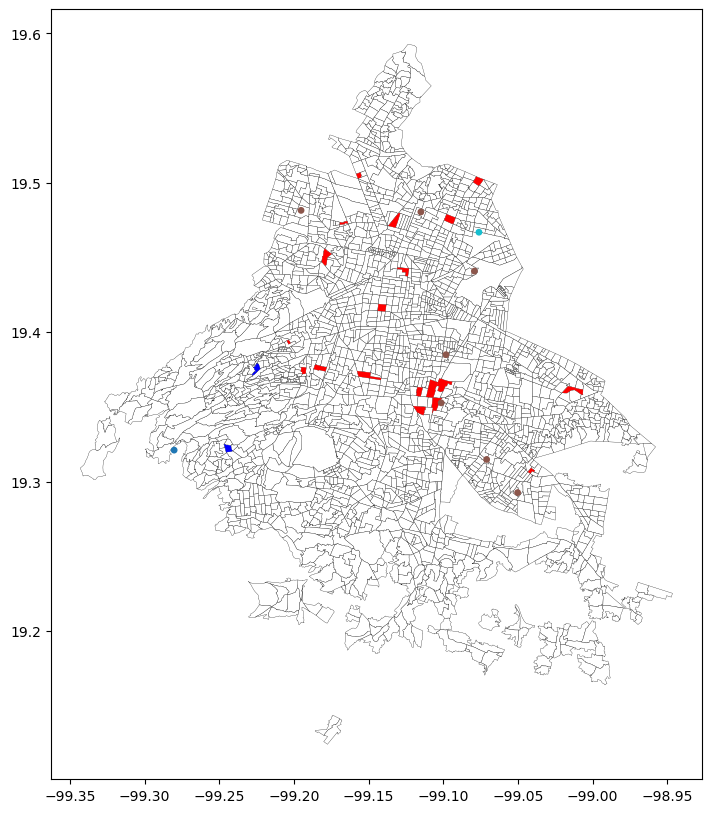

In [562]:
# Annotation: Overlay polygon groups 1 and 2 with the points that remain unassigned.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
alcgrupo2.plot(ax=ax,color='blue')
alcgrupo1.plot(ax=ax,color='red')
dftest5.plot(ax=ax,column='pobreza',markersize=15,categorical=True)

In [563]:
# Annotation: Inspect the poverty categories represented in the last constructed group.
grupo['pobreza'].unique()

array(['(18, 34]'], dtype=object)

## Reproducibility notes and items to review before publication

The notebook is fully annotated and its five empty cells have been removed. The original calculations remain unchanged, but the following issues should be resolved before publishing it as a clean end-to-end replication notebook:

1. Keep missing age as a separate category and correct the age-bin boundaries or labels.
2. Clarify whether the analysis includes all homicide types or only `HOMICIDIO_POR_ARMA_DE_FUEGO`.
3. Evaluate silhouette scores using the same standardized feature matrix supplied to DBSCAN.
4. Replace the fixed DBSCAN label `6` with an explicit and reproducible selection criterion.
5. Verify that `grafoarmfuego3.json`, `ageb_pobreza.shp`, and `total.shp` are distributed at the documented paths.
6. Assign `EPSG:4326` to the point GeoDataFrame before overlay operations.
7. Replace coordinate-string matching and exact point equality with a stable record identifier whenever possible.
8. Construct the graph neighbourhood as an explicit union of seed, first-hop, and second-hop nodes.
9. Remove the duplicated root before spatial group expansion.
10. Replace repeated nested spatial loops with `GeoPandas.sjoin` and repeated group blocks with a parameterized function.
11. Remove or repair the legacy `alcshp` cell before running the notebook from a clean kernel.

These observations distinguish the reproducible DBSCAN–Louvain core from exploratory cartographic development code without altering the stored results.
